# Python data analyst for cybersecurity attacks

In [87]:
# All needed imports go into this code slot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [88]:
#read the csv file and assign it to the data frame cb

data = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')
cb = pd.DataFrame(data)
cb.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


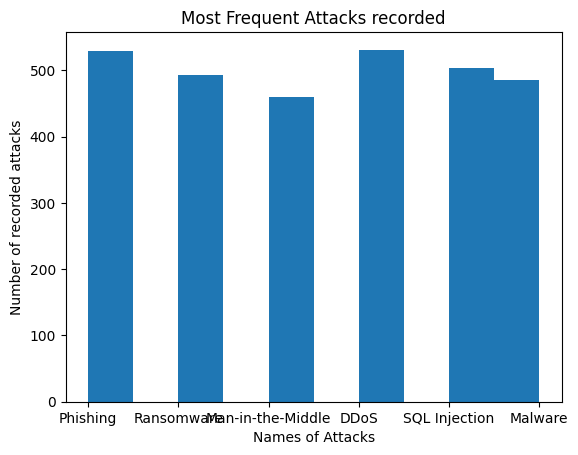

The most frequent Attack Type is DDoS with there being 531 number of attacks in total


In [89]:
#which attack type is the most frequent attack.

def frequent_type_check():

  return(cb['Attack Type']=='DDoS').sum()

plt.hist(cb['Attack Type'])
plt.xlabel('Names of Attacks')
plt.ylabel('Number of recorded attacks')
plt.title('Most Frequent Attacks recorded')
plt.show()
print(f"The most frequent Attack Type is DDoS with there being {frequent_type_check()} number of attacks in total")


Use monte carlo simulation to predict the outcome of certain attacks since all attacks are random, but prove they are random before doing the simulation


using the law of large numbers we run thousands of simulations to model the uncertainty and estimate the probability of outcomes before they happen or turn into a zero day risk. This is the challenge. Use the data given to run random samples of types of attacks to predict which attacks might be more common in the future and to prepare more for those type of attacks.

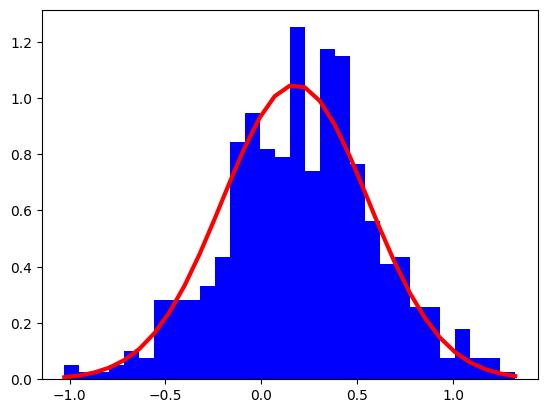

In [90]:
#created a normal distribution function to be reusable for all attack types in the csv

def normal_distribution_graph(dataMean, dataSTD, dataSize: int):
  dataRS = np.random.normal(dataMean, dataSTD, dataSize)
  count, bins, ignored = plt.hist(dataRS, 30, density=True, color='blue')
  plt.plot(bins, 1/(dataSTD * np.sqrt(2 * np.pi)) *
                np.exp( - (bins - dataMean)**2 / (2 * dataSTD**2) ),
          linewidth=3, color='r')
  plt.show()

phishingMean = (cb['Attack Type']=='Phishing').mean()
phishingSTD = (cb['Attack Type']=='Phishing').std()
size = 500

normal_distribution_graph(phishingMean, phishingSTD, size )

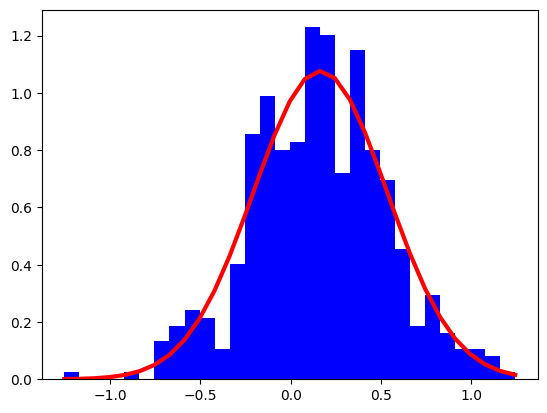

In [91]:
ransomwareMean = (cb['Attack Type']=='Ransomware').mean()
ransomwareSTD = (cb['Attack Type']=='Ransomware').std()
size: int = 450
normal_distribution_graph(ransomwareMean, ransomwareSTD, size)

In [92]:
#a function that will help automate the mean and median code instead of manually tpying it.

def all_types_distrobution(letter:str, sampleSize:int):

  #uniqueValues = cb['Attack Type'].unique()
  typeDict = {
      'a':'Phishing',
      'b':'Ransomware',
      'c':'Man-in-the-Middle',
      'd':'DDoS',
      'e':'SQL Injection',
      'f':'Malware'
  }

  mean = (cb['Attack Type']==typeDict[letter]).mean()
  standardDeviation = (cb['Attack Type']==typeDict[letter]).std()

  normal_distribution_graph(mean, standardDeviation, sampleSize)


Enter the letter to the corresponding Attack Type

a-Phishing, b-Ransomware, c-Man-in-the-middle, d-DDoS, e-SQL Injection f-Malware
a
Enter The sample size you would like the normal distrobution to randomly sample: 
500


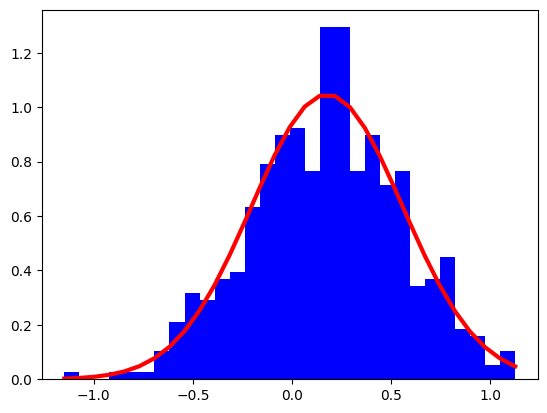

In [93]:
#user interface code

print('Enter the letter to the corresponding Attack Type\n')
print('a-Phishing, b-Ransomware, c-Man-in-the-middle, d-DDoS, e-SQL Injection', 'f-Malware')

userInputName = str(input())

print('Enter The sample size you would like the normal distrobution to randomly sample: ')
userInputSample = int(input())

all_types_distrobution(userInputName, userInputSample)